# GRU Tracker — Evaluation

Loads the saved `best_gru.pth` weights and computes:
- **Mean IoU** across the full test set
- **mAP @ IoU 0.50** and **mAP @ IoU 0.75** (detection-style proxies)
- **MAE** and **RMSE** on centre-point prediction error
- **Trajectory plot** for a sample sequence

> Make sure `best_gru.pth`, `scaler_X.pkl`, `scaler_Y.pkl` are already in your Drive from training.

In [1]:
# ── Shared imports & model definition needed for eval notebook ─────────────────
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import joblib
from google.colab import drive

drive.mount('/content/drive')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")


Mounted at /content/drive
Using device: cuda


## 1. Load Data & Helpers

In [2]:
BASE = '/content/drive/MyDrive/DNN_Dataset/Sequence_files/'

raw_train = np.load(BASE + 'sequences_rich_train.npy')
raw_test  = np.load(BASE + 'sequences_rich_test.npy')

print(f"raw_train: {raw_train.shape}")
print(f"raw_test:  {raw_test.shape}")

def extract_velocities(data):
    """
    Input:  (N, 11, 8)
    - features: x, y, w, h, drone_vx, drone_vy, drone_vz, altitude
    Output: (N, 10, 8)
    - features: dx, dy, w, h, drone_vx, drone_vy, drone_vz, altitude
    """
    vels = np.zeros_like(data)
    vels[:, 1:, 0] = data[:, 1:, 0] - data[:, :-1, 0]  # dx
    vels[:, 1:, 1] = data[:, 1:, 1] - data[:, :-1, 1]  # dy
    vels[:, :, 2:] = data[:, :, 2:]  # w, h + drone features
    return vels[:, 1:, :]  # drop first frame → (N, 10, 8)

# X = 10 frames of 8 features
X_train = extract_velocities(raw_train)  # (N, 10, 8)
X_test  = extract_velocities(raw_test)   # (N, 10, 8)

# Y = next frame velocity dx, dy, w, h
Y_train = np.zeros((raw_train.shape[0], 4))
Y_train[:, 0] = raw_train[:, 10, 0] - raw_train[:, 9, 0]
Y_train[:, 1] = raw_train[:, 10, 1] - raw_train[:, 9, 1]
Y_train[:, 2:] = raw_train[:, 10, 2:4]
Y_test = np.zeros((raw_test.shape[0], 4))
Y_test[:, 0] = raw_test[:, 10, 0] - raw_test[:, 9, 0]
Y_test[:, 1] = raw_test[:, 10, 1] - raw_test[:, 9, 1]
Y_test[:, 2:] = raw_test[:, 10, 2:4]

print(f"X_train: {X_train.shape} → Y_train: {Y_train.shape}")
print(f"X_test:  {X_test.shape}  → Y_test:  {Y_test.shape}")


raw_train: (141737, 11, 12)
raw_test:  (15749, 11, 12)
X_train: (141737, 10, 12) → Y_train: (141737, 4)
X_test:  (15749, 10, 12)  → Y_test:  (15749, 4)


## 2. Define GRU Architecture (must match training)

In [3]:
class GRUTracker(nn.Module):
    def __init__(self, input_size=12, hidden_size=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size,
                          num_layers=num_layers, batch_first=True,
                          dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_size, 4)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

model = GRUTracker().to(DEVICE)
print(f"GRU parameters: {sum(p.numel() for p in model.parameters()):,}")


GRU parameters: 154,116


## 3. Run Evaluation Metrics

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# GRU Tracker — Full Evaluation
# Metrics: Average IoU, IoU@0.5, IoU@0.75 (mAP proxies), MAE, RMSE, trajectory
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import torch, joblib
from pathlib import Path

SAVE_PATH = BASE + 'best_gru.pth'
scaler_X  = joblib.load(BASE + 'scaler_X.pkl')
scaler_Y  = joblib.load(BASE + 'scaler_Y.pkl')

model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

# ── IoU helper (x,y,w,h format) ───────────────────────────────────────────────
def iou_xywh(b1, b2):
    x1 = max(b1[0], b2[0]);  y1 = max(b1[1], b2[1])
    x2 = min(b1[0]+b1[2], b2[0]+b2[2])
    y2 = min(b1[1]+b1[3], b2[1]+b2[3])
    inter = max(0, x2-x1) * max(0, y2-y1)
    union = b1[2]*b1[3] + b2[2]*b2[3] - inter
    return inter / max(union, 1e-6)

# ── Run over full test set ─────────────────────────────────────────────────────
all_iou, all_mae_x, all_mae_y, all_rmse_vals = [], [], [], []

for i in range(len(raw_test)):
    sample = raw_test[i]                          # (11, 12)
    inp_hist = extract_velocities(sample[np.newaxis])[0]   # (10, 12)

    # Scale input
    scaled = scaler_X.transform(inp_hist)
    seq    = torch.tensor(scaled, dtype=torch.float32).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred_scaled = model(seq).cpu().numpy()

    pred_vel = scaler_Y.inverse_transform(pred_scaled)[0]  # [dx, dy, w, h]

    last_abs   = sample[9, :4]                             # last absolute box
    pred_box   = np.array([last_abs[0]+pred_vel[0], last_abs[1]+pred_vel[1], pred_vel[2], pred_vel[3]])
    gt_box     = sample[10, :4]

    iou_val = iou_xywh(pred_box, gt_box)
    all_iou.append(iou_val)

    # Centre-point absolute pixel error
    pred_cx, pred_cy = pred_box[0]+pred_box[2]/2, pred_box[1]+pred_box[3]/2
    gt_cx,   gt_cy   = gt_box[0]+gt_box[2]/2,     gt_box[1]+gt_box[3]/2
    all_mae_x.append(abs(pred_cx - gt_cx))
    all_mae_y.append(abs(pred_cy - gt_cy))
    all_rmse_vals.append((pred_cx - gt_cx)**2 + (pred_cy - gt_cy)**2)

all_iou      = np.array(all_iou)
all_mae_x    = np.array(all_mae_x)
all_mae_y    = np.array(all_mae_y)
all_rmse_vals = np.array(all_rmse_vals)

# ── Summary Metrics ───────────────────────────────────────────────────────────
mean_iou = all_iou.mean()
iou50    = (all_iou >= 0.50).mean() * 100   # AP@0.50 proxy
iou75    = (all_iou >= 0.75).mean() * 100   # AP@0.75 proxy
mae_x    = all_mae_x.mean()
mae_y    = all_mae_y.mean()
rmse_c   = np.sqrt(all_rmse_vals.mean())

print("=" * 55)
print(f"  Evaluation on {len(raw_test):,} test sequences")
print("=" * 55)
print(f"  Mean IoU                : {mean_iou:.4f}")
print(f"  mAP @ IoU 0.50 (%)     : {iou50:.2f}%")
print(f"  mAP @ IoU 0.75 (%)     : {iou75:.2f}%")
print(f"  MAE x-center (px)      : {mae_x:.2f}")
print(f"  MAE y-center (px)      : {mae_y:.2f}")
print(f"  Centre-point RMSE (px) : {rmse_c:.2f}")
print("=" * 55)


  Evaluation on 15,749 test sequences
  Mean IoU                : 0.9609
  mAP @ IoU 0.50 (%)     : 99.96%
  mAP @ IoU 0.75 (%)     : 99.51%
  MAE x-center (px)      : 0.79
  MAE y-center (px)      : 0.64
  Centre-point RMSE (px) : 2.00


## 4. Visualise Results

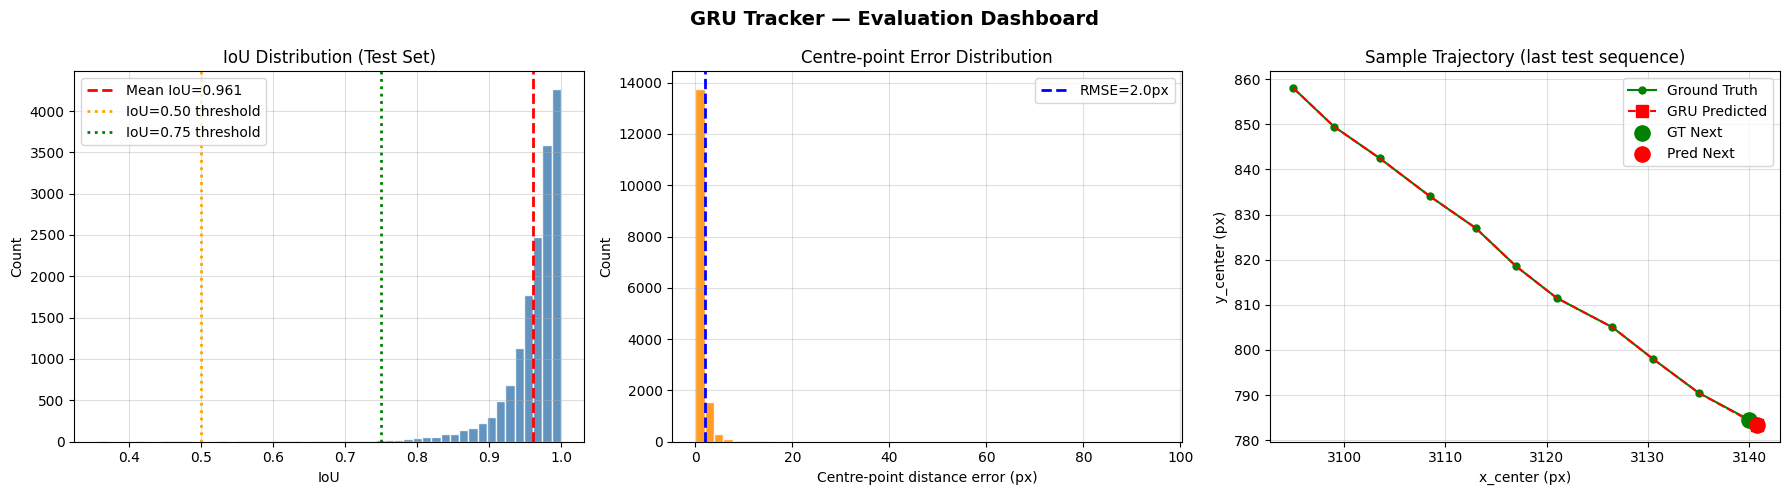


Saved evaluation figure -> /content/drive/MyDrive/DNN_Dataset/Sequence_files/gru_evaluation.png

Ground Truth next box : [3092.0, 762.0, 96.0, 45.0]
Predicted next box    : [np.float32(3091.7), np.float32(761.93), np.float32(98.1), np.float32(42.97)]


In [5]:
# ─── Plots ────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. IoU Distribution
axes[0].hist(all_iou, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(mean_iou, color='red',    linestyle='--', linewidth=2, label=f'Mean IoU={mean_iou:.3f}')
axes[0].axvline(0.50,      color='orange', linestyle=':',  linewidth=2, label='IoU=0.50 threshold')
axes[0].axvline(0.75,      color='green',  linestyle=':',  linewidth=2, label='IoU=0.75 threshold')
axes[0].set_xlabel('IoU'); axes[0].set_ylabel('Count')
axes[0].set_title('IoU Distribution (Test Set)')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

# 2. Centre-point error distribution
centre_err = np.sqrt(all_rmse_vals)
axes[1].hist(centre_err, bins=50, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].axvline(rmse_c, color='blue', linestyle='--', linewidth=2, label=f'RMSE={rmse_c:.1f}px')
axes[1].set_xlabel('Centre-point distance error (px)')
axes[1].set_ylabel('Count')
axes[1].set_title('Centre-point Error Distribution')
axes[1].legend(); axes[1].grid(True, alpha=0.4)

# 3. Sample trajectory
sample_raw    = raw_test[0]
inp_hist      = extract_velocities(sample_raw[np.newaxis])[0]
scaled        = scaler_X.transform(inp_hist)
seq           = torch.tensor(scaled, dtype=torch.float32).unsqueeze(0).to(DEVICE)
with torch.no_grad():
    pred_scaled = model(seq).cpu().numpy()
pred_vel      = scaler_Y.inverse_transform(pred_scaled)[0]
last_abs      = sample_raw[9, :4]
pred_box      = [last_abs[0]+pred_vel[0], last_abs[1]+pred_vel[1], pred_vel[2], pred_vel[3]]
gt_next       = sample_raw[10, :4].tolist()
history_boxes = [sample_raw[i, :4].tolist() for i in range(10)]

xs_gt   = [b[0]+b[2]/2 for b in history_boxes] + [gt_next[0]+gt_next[2]/2]
ys_gt   = [b[1]+b[3]/2 for b in history_boxes] + [gt_next[1]+gt_next[3]/2]
xs_pred = [b[0]+b[2]/2 for b in history_boxes] + [pred_box[0]+pred_box[2]/2]
ys_pred = [b[1]+b[3]/2 for b in history_boxes] + [pred_box[1]+pred_box[3]/2]

axes[2].plot(xs_gt,   ys_gt,   'g-o',  label='Ground Truth',  markersize=5)
axes[2].plot(xs_pred, ys_pred, 'r--s', label='GRU Predicted', markersize=8, markevery=[-1])
axes[2].scatter(xs_gt[-1],   ys_gt[-1],   color='green', s=120, zorder=5, label='GT Next')
axes[2].scatter(xs_pred[-1], ys_pred[-1], color='red',   s=120, zorder=5, label='Pred Next')
axes[2].set_xlabel('x_center (px)'); axes[2].set_ylabel('y_center (px)')
axes[2].set_title('Sample Trajectory (last test sequence)')
axes[2].legend(); axes[2].grid(True, alpha=0.4)

plt.suptitle('GRU Tracker — Evaluation Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE + 'gru_evaluation.png', dpi=150)
plt.show()

print(f"\nSaved evaluation figure -> {BASE}gru_evaluation.png")
print(f"\nGround Truth next box : {[round(v,2) for v in gt_next]}")
print(f"Predicted next box    : {[round(v,2) for v in pred_box]}")
